In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from scipy.sparse import load_npz



              precision    recall  f1-score   support

           0       0.87      0.52      0.65       490
           1       0.94      0.99      0.96      3474

    accuracy                           0.93      3964
   macro avg       0.90      0.76      0.81      3964
weighted avg       0.93      0.93      0.92      3964



In [5]:
X_train = load_npz('X_train_tfidf.npz')
X_test = load_npz('X_test_tfidf.npz')
y_train = pd.read_csv('y_train.csv').squeeze('columns')
y_test = pd.read_csv('y_test.csv').squeeze('columns')


In [6]:
import joblib
model = LogisticRegression()
model.fit(X_train, y_train)


joblib.dump(model, "../models/best_model.pkl")


['../models/best_model.pkl']

In [7]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {100 * accuracy}%")


Accuracy: 93.11301715438951%


In [8]:
print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       0.87      0.52      0.65       490
           1       0.94      0.99      0.96      3474

    accuracy                           0.93      3964
   macro avg       0.90      0.76      0.81      3964
weighted avg       0.93      0.93      0.92      3964



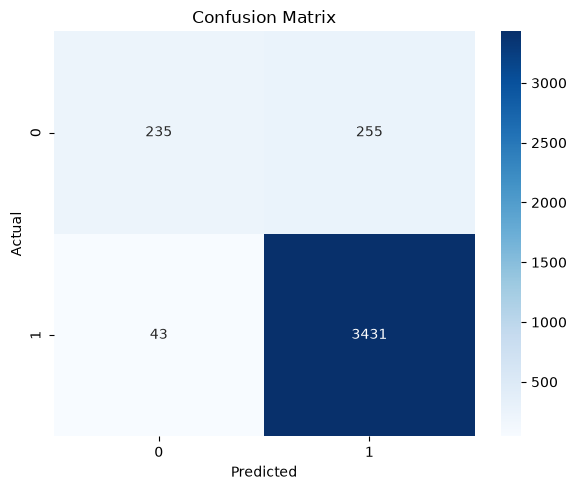

In [9]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
print(f'accuracy: {accuracy*100}')
print("Precision:", precision * 100)
print("Recall:", recall * 100)
print("F1 Score:", f1 * 100)

accuracy: 93.11301715438951
Precision: 93.62224039247614
Recall: 98.87737478411054
F1 Score: 96.17812631505383
